In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import os
import sys
# Add parent directory to path to import modules from one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)
from model_IAI import finetune_oct_impute, get_preprocessor_with_impute, evaluate_binary_oct

# Add parent directory to path to import modules from one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, parent_dir)
from sklearn.datasets import fetch_openml

def load_fico_heloc_openml(data_id=45554, make_minority_one=True):
    """
    Loads the OpenML 'FICO-HELOC-cleaned' dataset (commonly referenced as OpenML d/45554),
    returns a DataFrame with columns: ENROLID, target, <features...>.

    - Handles RiskPerformance (Good/Bad) if present.
    - Treats -8 and -9 as missing (per common HELOC handling).
    """
    bunch = fetch_openml(data_id=data_id, as_frame=True)  # or name="FICO-HELOC-cleaned"
    X = bunch.data.copy()
    y = bunch.target.copy()

    # Unify into a single frame
    df = X.copy()
    df["__y__"] = y

    # Convert label to 0/1
    # Common: RiskPerformance in {"Good","Bad"} (Bad = worse outcome)
    y_str = df["__y__"].astype(str).str.strip().str.lower()
    if set(y_str.unique()).issubset({"good", "bad"}):
        df["target"] = (y_str == "bad").astype(int)
    else:
        # fallback: if already numeric or other coding
        y_num = pd.to_numeric(df["__y__"], errors="coerce")
        if set(y_num.dropna().unique()).issubset({0, 1}):
            df["target"] = y_num.astype(int)
        else:
            # map minority value to 1
            vc = y_num.value_counts(dropna=True)
            minority_val = vc.idxmin()
            df["target"] = (y_num == minority_val).astype(int)

    df = df.drop(columns=["__y__"])

    # Treat -8 / -9 as missing (common in HELOC usage)
    # (works whether the data is int/float or object)
    df = df.replace({-8: np.nan, -9: np.nan, "-8": np.nan, "-9": np.nan})

    # Add ENROLID
    df["ENROLID"] = np.arange(1, len(df) + 1, dtype=np.int64)
    cols = ["ENROLID", "target"] + [c for c in df.columns if c not in ["ENROLID", "target"]]
    df = df[cols]

    # Ensure numeric features where possible
    feature_cols = [c for c in df.columns if c not in ["ENROLID", "target"]]
    for c in feature_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Optionally ensure minority class is labeled 1 (your code assumes cases=1)
    if make_minority_one:
        vc = df["target"].value_counts()
        if vc.get(1, 0) > vc.get(0, 0):
            df["target"] = 1 - df["target"]

    print("\n=== FICO HELOC LOADED (OpenML) ===")
    print("Shape:", df.shape)
    print("Target counts:\n", df["target"].value_counts())
    return df

def setup_feature_columns(df, target_col="target"):
    """
    APS: typically all features are numeric after coercion.
    """
    feature_cols = [c for c in df.columns if c not in ["ENROLID", target_col]]

    # After coercion, treat as numeric
    cat_cols = df[feature_cols].select_dtypes(include=["object", "category"]).columns.tolist()
    if len(cat_cols) > 0:
        # In APS, this usually indicates you missed numeric coercion.
        print("⚠️ Warning: found non-numeric feature cols (expected none):", cat_cols[:10])

    numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()

    # Binary detection (rare in APS but keep consistent with your framework)
    bin_cols = []
    for col in numeric_cols:
        u = df[col].dropna().unique()
        if len(u) <= 2 and set(u).issubset({0, 1, 0.0, 1.0}):
            bin_cols.append(col)

    true_num_cols = [c for c in numeric_cols if c not in bin_cols]

    print(f"\n=== APS COLUMN SETUP ===")
    print(f"Total features: {len(feature_cols)}")
    print(f"Categorical columns: {len(cat_cols)}")
    print(f"Binary columns: {len(bin_cols)}")
    print(f"True numeric columns: {len(true_num_cols)}")

    return feature_cols, cat_cols, true_num_cols, bin_cols

def create_train_test_split(df, target_col='target', test_size=0.3, val_size=0.5, random_state=123):
    """
    Create train/val/test splits similar to the main script.
    Returns: train_df, val_df, test_df
    """
    # First split: train vs (val+test)
    train_df, temp_df = train_test_split(
        df, 
        test_size=test_size, 
        stratify=df[target_col], 
        random_state=random_state
    )
    
    # Second split: val vs test (from temp_df)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=val_size,
        stratify=temp_df[target_col],
        random_state=random_state
    )
    
    print(f"\n=== DATA SPLITS ===")
    print(f"Train: {len(train_df):,} samples")
    print(f"  - Minority: {(train_df[target_col] == 1).sum():,}")
    print(f"  - Majority: {(train_df[target_col] == 0).sum():,}")
    print(f"Val: {len(val_df):,} samples")
    print(f"  - Minority: {(val_df[target_col] == 1).sum():,}")
    print(f"  - Majority: {(val_df[target_col] == 0).sum():,}")
    print(f"Test: {len(test_df):,} samples")
    print(f"  - Minority: {(test_df[target_col] == 1).sum():,}")
    print(f"  - Majority: {(test_df[target_col] == 0).sum():,}")
    
    return train_df, val_df, test_df


def precompute_case_control_distances(
    train_df, target_col, feature_cols,
    cat_columns, true_num_columns,
    dataset_name, seed=123
):
    import os
    import numpy as np
    from precompute_distances import compute_distances_batched, save_distances_hdf5

    cases = train_df[train_df[target_col] == 1].copy()
    controls = train_df[train_df[target_col] == 0].copy()

    X_cases = cases[feature_cols].copy()
    X_controls = controls[feature_cols].copy()

    print(f"Cases (minority): {len(cases):,}")
    print(f"Controls (majority): {len(controls):,}")

    used_cat = [c for c in cat_columns if c in X_controls.columns]
    used_num = [c for c in true_num_columns if c in X_controls.columns]

    # Ensure we don't drop any features unintentionally
    covered = set(used_cat + used_num)
    dropped = [c for c in feature_cols if c not in covered]
    assert len(dropped) == 0, f"These features would be dropped by the preprocessor: {dropped[:10]}"

    preprocessor = get_preprocessor_with_impute(
        categorical_cols=used_cat,
        numeric_cols=used_num,
        verbose=True
    )

    X_controls_processed = preprocessor.fit_transform(X_controls).astype(np.float32)
    X_cases_processed = preprocessor.transform(X_cases).astype(np.float32)

    assert np.isfinite(X_controls_processed).all()
    assert np.isfinite(X_cases_processed).all()

    distances = compute_distances_batched(
        X_controls_processed, X_cases_processed,
        batch_size=1000, dtype=np.float32
    )

    print(f"  Distance matrix shape: {distances.shape}")
    print(f"  Distance range: [{distances.min():.3f}, {distances.max():.3f}]")
    print(f"  Distance mean: {distances.mean():.3f}")

    output_dir = "./precomputed_distances"
    os.makedirs(output_dir, exist_ok=True)
    h5_path = os.path.join(output_dir, f"distances_{dataset_name}_seed_{seed}.h5")

    majority_enrolids = controls["ENROLID"].to_numpy()
    minority_enrolids = cases["ENROLID"].to_numpy()

    save_distances_hdf5(distances, majority_enrolids, minority_enrolids, h5_path, compression="gzip")
    print(f"\n✓ Saved distances to: {h5_path}")

    return h5_path, X_controls_processed, majority_enrolids

def make_biased_observed_dataset(
    df_full: pd.DataFrame,
    target_col: str = "target",
    pos_label: int = 1,
    target_pos_frac: float = 0.03,   # e.g., 0.02–0.05
    seed: int = 123,
    keep_all_negatives: bool = True,
):
    """
    Create a biased 'observed' dataset by randomly dropping positives so that
    P(Y=1) ~ target_pos_frac, mimicking observation bias toward negatives.

    Assumes df_full already contains ENROLID and target.
    """
    assert 0 < target_pos_frac < 0.5, "target_pos_frac should be in (0, 0.5) for 'rare positives'."
    rng = np.random.default_rng(seed)

    df = df_full.copy()
    pos = df[df[target_col] == pos_label]
    neg = df[df[target_col] != pos_label]

    n_neg = len(neg)
    # Want: n_pos_keep / (n_pos_keep + n_neg_keep) = target_pos_frac
    # If keeping all negatives: n_neg_keep = n_neg
    n_neg_keep = n_neg if keep_all_negatives else int(np.floor(len(df) * (1 - target_pos_frac)))
    if not keep_all_negatives:
        # Optional: downsample negatives too (not needed for your story)
        neg_keep_idx = rng.choice(neg.index.to_numpy(), size=n_neg_keep, replace=False)
        neg = df.loc[neg_keep_idx]
        n_neg = len(neg)

    n_pos_keep = int(np.floor((target_pos_frac / (1 - target_pos_frac)) * n_neg))
    n_pos_keep = max(1, min(n_pos_keep, len(pos)))

    pos_keep_idx = rng.choice(pos.index.to_numpy(), size=n_pos_keep, replace=False)
    pos_kept = df.loc[pos_keep_idx]

    df_obs = pd.concat([neg, pos_kept], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)

    frac = df_obs[target_col].mean()
    print("\n=== BIASED OBSERVED HELOC DATASET ===")
    print(f"Requested target positive fraction: {target_pos_frac:.3f}")
    print(f"Achieved positive fraction:        {frac:.3f}")
    print("Counts:\n", df_obs[target_col].value_counts().sort_index())
    return df_obs

df_heloc = load_fico_heloc_openml()


=== FICO HELOC LOADED (OpenML) ===
Shape: (9871, 25)
Target counts:
 target
0    5136
1    4735
Name: count, dtype: int64


In [6]:
import inspect
import pandas as pd
import numpy as np
import os
import importlib
import kcenter_hyperparameter_search_global
importlib.reload(kcenter_hyperparameter_search_global)
from kcenter_hyperparameter_search_global import run_global_kcenter_matching, build_undersampled_dataset

from sklearn.impute import SimpleImputer
from imblearn.under_sampling import RandomUnderSampler  # add others if needed

def evaluate_oct_safe(model, X_eval, y_eval, preproc, featnames, **kwargs):
    """
    Calls your evaluate_binary_oct but only passes kwargs that exist in its signature.
    This avoids crashing if your local evaluate_binary_oct has slightly different args.
    """
    sig = inspect.signature(evaluate_binary_oct)
    allowed = set(sig.parameters.keys())
    filtered = {k: v for k, v in kwargs.items() if k in allowed}
    return evaluate_binary_oct(model, X_eval, y_eval, preproc, featnames, **filtered)

def pick_best_by_val_pr_auc(rows):
    """rows: list of dicts each with key 'val_pr_auc'"""
    vals = [r.get("val_pr_auc", np.nan) for r in rows]
    if np.all(np.isnan(vals)):
        return None
    return rows[int(np.nanargmax(vals))]


In [7]:
def run_one_heloc_setting(
    df_heloc_full,
    seed: int,
    pos_frac: float,
    results_root: str,
    # OCT grids
    OCT_DEPTHS=[5,7,9],
    OCT_MINBUCKETS=[25,50,100],
    OCT_CPS=[1e-5, 1e-4, 1e-3, 1e-2],
    OCT_DEPTHS_CUR=[7,9],
    OCT_MINBUCKETS_CUR=[25,50],
    OCT_CPS_CUR=[1e-5, 1e-4],
    # curation grid (keep small if time is tight)
    SEED_METHODS=("random","smart","centroid"),
    CASE_WEIGHTINGS=(None, "density_inverse"),
    USE_ADAPTIVE_POOL=(False,),
    MATCHING_RATIOS=(1,),
):
    """
    Returns:
      - baseline_test_metrics dict
      - curated_test_metrics dict (best config selected by validation PR-AUC)
      - bookkeeping info dict
    """
    DATASET_NAME = f"fico_heloc_obs{int(pos_frac*1000):03d}_seed{seed}"
    out_dir = os.path.join(results_root, DATASET_NAME)
    os.makedirs(out_dir, exist_ok=True)

    # 1) Bias then split (your notebook functions)
    df_obs = make_biased_observed_dataset(
        df_heloc_full, target_col="target",
        target_pos_frac=pos_frac, seed=seed
    )
    feature_cols, CAT_COLS, TRUE_NUM_COLS, BIN_COLS = setup_feature_columns(df_obs)
    train_df, val_df, test_df = create_train_test_split(df_obs, random_state=seed)

    X_val, y_val = val_df[feature_cols], val_df["target"]
    X_test, y_test = test_df[feature_cols], test_df["target"]

    # 2) Distances (train only)
    h5_path, _, _ = precompute_case_control_distances(
        train_df, "target", feature_cols,
        CAT_COLS, TRUE_NUM_COLS,
        dataset_name=DATASET_NAME, seed=seed
    )

    # 3) Baseline OCT: tune on val, evaluate on test
    base_model, base_params, _, base_preproc, base_featnames = finetune_oct_impute(
        X_train=train_df[feature_cols],
        y_train=train_df["target"],
        X_val=X_val, y_val=y_val,
        categorical_cols=CAT_COLS,
        numeric_cols=TRUE_NUM_COLS,
        depths=OCT_DEPTHS, minbuckets=OCT_MINBUCKETS, cps=OCT_CPS
    )

    baseline_test = evaluate_oct_safe(
        base_model, X_test, y_test,
        base_preproc, base_featnames,
        results_dir=out_dir,
        save_suffix="baseline",
        X_val_df=X_val, y_val=y_val,   # only used if your evaluate fn supports it
    )

    # 4) Curated: grid search over curation configs (select on VAL PR-AUC)
    dnn_dir = os.path.join("./precomputed_distances", f"global_dnn_{DATASET_NAME}")
    os.makedirs(dnn_dir, exist_ok=True)

    candidates = []
    for seed_method in SEED_METHODS:
        for case_weighting in CASE_WEIGHTINGS:
            for use_adaptive_pool in USE_ADAPTIVE_POOL:
                for matching_ratio in MATCHING_RATIOS:

                    cfg_name = f"seed_{seed_method}_cw_{case_weighting}_pool_{use_adaptive_pool}_ratio_{matching_ratio}"

                    matching_result = run_global_kcenter_matching(
                        train_pd=train_df,
                        target_col="target",
                        feature_cols=feature_cols,
                        pn_h5_path=h5_path,
                        matching_ratio=matching_ratio,
                        case_weighting=case_weighting,
                        use_adaptive_pool=use_adaptive_pool,
                        seed_method=seed_method,
                        CAT_COLUMNS=CAT_COLS,
                        TRUE_NUM_COLUMNS=TRUE_NUM_COLS,
                        COST_COLUMNS=None,
                        dnn_out_dir=dnn_dir,
                    )

                    undersampled_train = build_undersampled_dataset(
                        train_pd=train_df,
                        matching_result=matching_result,
                        target_col="target",
                        matching_ratio=matching_ratio,
                    )

                    cur_model, cur_params, _, cur_preproc, cur_featnames = finetune_oct_impute(
                        X_train=undersampled_train[feature_cols],
                        y_train=undersampled_train["target"],
                        X_val=X_val, y_val=y_val,
                        categorical_cols=CAT_COLS,
                        numeric_cols=TRUE_NUM_COLS,
                        depths=OCT_DEPTHS_CUR, minbuckets=OCT_MINBUCKETS_CUR, cps=OCT_CPS_CUR
                    )

                    # IMPORTANT: select on VALIDATION, not test
                    val_metrics = evaluate_oct_safe(
                        cur_model, X_val, y_val,
                        cur_preproc, cur_featnames,
                        results_dir=None,
                        save_suffix=None
                    )

                    candidates.append({
                        "config_name": cfg_name,
                        "seed_method": seed_method,
                        "case_weighting": case_weighting,
                        "use_adaptive_pool": use_adaptive_pool,
                        "matching_ratio": matching_ratio,
                        "val_pr_auc": float(val_metrics.get("pr_auc", np.nan)),
                        "_model": cur_model,
                        "_preproc": cur_preproc,
                        "_featnames": cur_featnames,
                        "_oct_params": cur_params,
                        "_undersampled_n": int(len(undersampled_train)),
                        "_train_pos": int(train_df["target"].sum()),
                        "_train_n": int(len(train_df)),
                    })

    best = pick_best_by_val_pr_auc(candidates)
    if best is None:
        curated_test = { "error": "All configs returned NaN val_pr_auc" }
        best_cfg = None
    else:
        curated_test = evaluate_oct_safe(
            best["_model"], X_test, y_test,
            best["_preproc"], best["_featnames"],
            results_dir=out_dir,
            save_suffix="curated_best",
            X_val_df=X_val, y_val=y_val
        )
        best_cfg = {k: best[k] for k in ["config_name","seed_method","case_weighting","use_adaptive_pool","matching_ratio","val_pr_auc","_undersampled_n"]}
        best_cfg["oct_params"] = best["_oct_params"]

    info = {
        "seed": seed,
        "pos_frac": pos_frac,
        "dataset_name": DATASET_NAME,
        "out_dir": out_dir,
        "train_pos": int(train_df["target"].sum()),
        "train_n": int(len(train_df)),
        "val_pos": int(val_df["target"].sum()),
        "val_n": int(len(val_df)),
        "test_pos": int(test_df["target"].sum()),
        "test_n": int(len(test_df)),
        "baseline_oct_params": base_params,
        "best_cfg": best_cfg
    }
    return baseline_test, curated_test, info


In [18]:
SEEDS = [0, 1, 2, 3, 4]                  # 5 seeds
POS_FRACS = [0.02, 0.03, 0.05, 0.07, 0.10]  # 2–10%
RESULTS_ROOT = "./heloc_sweep_results"
os.makedirs(RESULTS_ROOT, exist_ok=True)
SEED_METHODS=("random"), #,"smart","centroid"
CASE_WEIGHTINGS=(None), #, "density_inverse"
records = []

for pos_frac in POS_FRACS:
    for seed in SEEDS:
        print("\n" + "="*90)
        print(f"RUN: pos_frac={pos_frac:.3f}, seed={seed}")
        print("="*90)

        base_test, cur_test, info = run_one_heloc_setting(
            df_heloc_full=df_heloc,
            seed=seed,
            pos_frac=pos_frac,
            results_root=RESULTS_ROOT,
            SEED_METHODS=SEED_METHODS,
            CASE_WEIGHTINGS=CASE_WEIGHTINGS
        )

        def flatten(prefix, d):
            out = {}
            if isinstance(d, dict):
                for k,v in d.items():
                    if isinstance(v, (int,float,str,bool)) or v is None:
                        out[f"{prefix}{k}"] = v
            return out

        row = {}
        row.update(info)
        row.update(flatten("base_", base_test))
        row.update(flatten("cur_", cur_test))
        records.append(row)

results_df = pd.DataFrame(records)
results_df.to_csv(os.path.join(RESULTS_ROOT, "heloc_sweep_raw.csv"), index=False)
print("\nSaved raw results to:", os.path.join(RESULTS_ROOT, "heloc_sweep_raw.csv"))
results_df.head()



RUN: pos_frac=0.020, seed=0

=== BIASED OBSERVED HELOC DATASET ===
Requested target positive fraction: 0.020
Achieved positive fraction:        0.020
Counts:
 target
0    5136
1     104
Name: count, dtype: int64

=== APS COLUMN SETUP ===
Total features: 23
Categorical columns: 0
Binary columns: 0
True numeric columns: 23

=== DATA SPLITS ===
Train: 3,668 samples
  - Minority: 73
  - Majority: 3,595
Val: 786 samples
  - Minority: 16
  - Majority: 770
Test: 786 samples
  - Minority: 15
  - Majority: 771
Cases (minority): 73
Controls (majority): 3,595
→ Building preprocessor w/ imputation:
   • Cat: impute(most_frequent) + OHE on: []
   • Num: impute(median) + scale on: ['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M', 'P

Computing distances: 100%|██████████| 4/4 [00:00<00:00, 1194.79it/s]

  Distance matrix shape: (3595, 73)
  Distance range: [1.202, 32.349]
  Distance mean: 6.593

Saving to HDF5: ./precomputed_distances/distances_fico_heloc_obs020_seed0_seed_0.h5
  ✓ Saved 1.0 MB

✓ Saved distances to: ./precomputed_distances/distances_fico_heloc_obs020_seed0_seed_0.h5
Finetuning OCT (with imputation) for best PR-AUC
→ Building preprocessor w/ imputation:
   • Cat: impute(most_frequent) + OHE on: []
   • Num: impute(median) + scale on: ['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NumInqLast6Mexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2N

Best params: (5, 25, 1e-05) @ val PR-AUC: 0.0204
Test dataset for OCT application: 786 samples
✓ Predictions completed
Computing optimal thresholds on validation set (786 samples)
  Applied validation-set thresholds to test set for evaluation
✓ Saved OCT predictions to: ./heloc_sweep_results/fico_heloc_obs020_seed0/predictions/oct_predictions_baseline.csv
⚠ Could not extract individual splits
   Tree uses 0 feature(s): []
   Consider using learner.show_tree() for visualization
⚠ No splits extracted (tree has 1 node(s))
   This may indicate:
   1. Tree is a single leaf (no splits)
   2. IAI API methods differ from expected
   3. Check IAI docs for correct split extraction method
AUC score: 0.500
PR-AUC (Average Precision): 0.019
Best MCC (test set, threshold from val): 0.000 @ threshold=0.019902
Sensitivity (Recall) @MCC*: 1.000
Specificity @MCC*: 0.000
Balanced (G-mean) recall (test set, threshold from val): 0.000
Balanced (G-mean) specificity (test set, threshold from val): 1.000
Numb

Computing distances: 100%|██████████| 4/4 [00:00<00:00, 2416.77it/s]

...

  ✓ Saved 5.1 MB

✓ Saved distances to: ./precomputed_distances/distances_fico_heloc_obs100_seed3_seed_3.h5
Finetuning OCT (with imputation) for best PR-AUC
→ Building preprocessor w/ imputation:
   • Cat: impute(most_frequent) + OHE on: []
   • Num: impute(median) + scale on: ['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NumInqLast6Mexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance']
Best params: (7, 25, 0.001) @ val PR-AUC: 0.2663
Test dataset for OCT application: 856 samples
✓ Predictions completed
Comput

Computing distances: 100%|██████████| 4/4 [00:00<00:00, 683.28it/s]

  Distance matrix shape: (3595, 399)
  Distance range: [0.687, 38.628]
  Distance mean: 6.439

Saving to HDF5: ./precomputed_distances/distances_fico_heloc_obs100_seed4_seed_4.h5


  ✓ Saved 5.0 MB

✓ Saved distances to: ./precomputed_distances/distances_fico_heloc_obs100_seed4_seed_4.h5
Finetuning OCT (with imputation) for best PR-AUC
→ Building preprocessor w/ imputation:
   • Cat: impute(most_frequent) + OHE on: []
   • Num: impute(median) + scale on: ['ExternalRiskEstimate', 'MSinceOldestTradeOpen', 'MSinceMostRecentTradeOpen', 'AverageMInFile', 'NumSatisfactoryTrades', 'NumTrades60Ever2DerogPubRec', 'NumTrades90Ever2DerogPubRec', 'PercentTradesNeverDelq', 'MSinceMostRecentDelq', 'MaxDelq2PublicRecLast12M', 'MaxDelqEver', 'NumTotalTrades', 'NumTradesOpeninLast12M', 'PercentInstallTrades', 'MSinceMostRecentInqexcl7days', 'NumInqLast6M', 'NumInqLast6Mexcl7days', 'NetFractionRevolvingBurden', 'NetFractionInstallBurden', 'NumRevolvingTradesWBalance', 'NumInstallTradesWBalance', 'NumBank2NatlTradesWHighUtilization', 'PercentTradesWBalance']
Best params: (7, 25, 1e-05) @ val PR-AUC: 0.2885
Test dataset for OCT application: 856 samples
✓ Predictions completed
Comput

,seed,pos_frac,dataset_name,out_dir,train_pos,train_n,val_pos,val_n,test_pos,test_n,...,cur_auc,cur_pr_auc,cur_best_mcc,cur_best_mcc_threshold,cur_recall_mcc,cur_precision_mcc,cur_optimal_f1,cur_balanced_recall_gmean,cur_balanced_specificity_gmean,cur_precision_gmean
0,0,0.02,fico_heloc_obs020_seed0,./heloc_sweep_results/fico_heloc_obs020_seed0,73,3668,16,786,15,786,...,0.565110,0.022665,0.040026,0.515116,0.400000,0.028037,0.052402,0.400000,0.730220,0.028037
1,1,0.02,fico_heloc_obs020_seed1,./heloc_sweep_results/fico_heloc_obs020_seed1,73,3668,15,786,16,786,...,0.390422,0.019415,0.026418,0.732941,0.125000,0.033333,0.052632,0.250000,0.584416,0.012346
2,2,0.02,fico_heloc_obs020_seed2,./heloc_sweep_results/fico_heloc_obs020_seed2,73,3668,16,786,15,786,...,0.684176,0.034139,0.109430,0.489439,0.666667,0.041667,0.078431,0.666667,0.701686,0.041667
3,3,0.02,fico_heloc_obs020_seed3,./heloc_sweep_results/fico_heloc_obs020_seed3,73,3668,16,786,15,786,...,0.718936,0.034269,0.119823,0.476042,0.933333,0.035354,0.068127,0.933333,0.504540,0.035354
4,4,0.02,fico_heloc_obs020_seed4,./heloc_sweep_results/fico_heloc_obs020_seed4,73,3668,16,786,15,786,...,0.664851,0.034764,0.110766,0.517633,0.533333,0.048485,0.088889,0.533333,0.796368,0.048485


In [19]:
# Statistical analysis and visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load results if not already in memory
if 'results_df' not in locals():
    results_df = pd.read_csv(os.path.join(RESULTS_ROOT, "heloc_sweep_raw.csv"))

# Calculate p-values for paired-per-seed comparisons (one-sided: curation > baseline)
metrics = ['auc', 'pr_auc', 'best_mcc']
pvalue_results = []

for pos_frac in POS_FRACS:
    df_subset = results_df[results_df['pos_frac'] == pos_frac].copy()
    
    for metric in metrics:
        base_col = f'base_{metric}'
        cur_col = f'cur_{metric}'
        
        if base_col in df_subset.columns and cur_col in df_subset.columns:
            base_vals = df_subset[base_col].values
            cur_vals = df_subset[cur_col].values
            differences = cur_vals - base_vals
            
            # Paired t-test (one-sided: curation > baseline)
            # H0: mean difference <= 0, H1: mean difference > 0
            t_stat, p_value = stats.ttest_rel(cur_vals, base_vals, alternative='greater')
            
            # Also calculate mean difference and std
            mean_diff = differences.mean()
            std_diff = differences.std()
            mean_base = base_vals.mean()
            mean_cur = cur_vals.mean()
            std_base = base_vals.std()
            std_cur = cur_vals.std()
            
            pvalue_results.append({
                'pos_frac': pos_frac,
                'metric': metric,
                'p_value': p_value,
                'mean_diff': mean_diff,
                'std_diff': std_diff,
                'mean_base': mean_base,
                'mean_cur': mean_cur,
                'std_base': std_base,
                'std_cur': std_cur,
                't_statistic': t_stat
            })

pvalue_df = pd.DataFrame(pvalue_results)
print("\n=== P-VALUE RESULTS (One-sided: Curation > Baseline) ===")
print(pvalue_df.to_string(index=False))

# Save p-values
pvalue_df.to_csv(os.path.join(RESULTS_ROOT, "heloc_sweep_pvalues.csv"), index=False)
print(f"\nSaved p-values to: {os.path.join(RESULTS_ROOT, 'heloc_sweep_pvalues.csv')}")



=== P-VALUE RESULTS (One-sided: Curation > Baseline) ===
 pos_frac   metric  p_value  mean_diff  std_diff  mean_base  mean_cur  std_base  std_cur  t_statistic
     0.02      auc 0.076264   0.104699  0.118716   0.500000  0.604699  0.000000 0.118716     1.763866
     0.02   pr_auc 0.025067   0.009712  0.007003   0.019338  0.029051  0.000509 0.006624     2.773818
     0.02 best_mcc 0.007421   0.081293  0.039646   0.000000  0.081293  0.000000 0.039646     4.100913
     0.03      auc 0.783794  -0.061165  0.140283   0.631690  0.570525  0.115672 0.087243    -0.872023
     0.03   pr_auc 0.898697  -0.054758  0.071943   0.104064  0.049306  0.068706 0.024763    -1.522247
     0.03 best_mcc 0.670521  -0.030501  0.128175   0.111449  0.080948  0.098999 0.053576    -0.475922
     0.05      auc 0.931471  -0.066020  0.071148   0.664176  0.598156  0.043153 0.058755    -1.855853
     0.05   pr_auc 0.966349  -0.033706  0.027045   0.117557  0.083851  0.009075 0.024888    -2.492539
     0.05 best_mcc 0.764


Saved visualization to: ./heloc_sweep_results/heloc_sweep_metrics_comparison.png


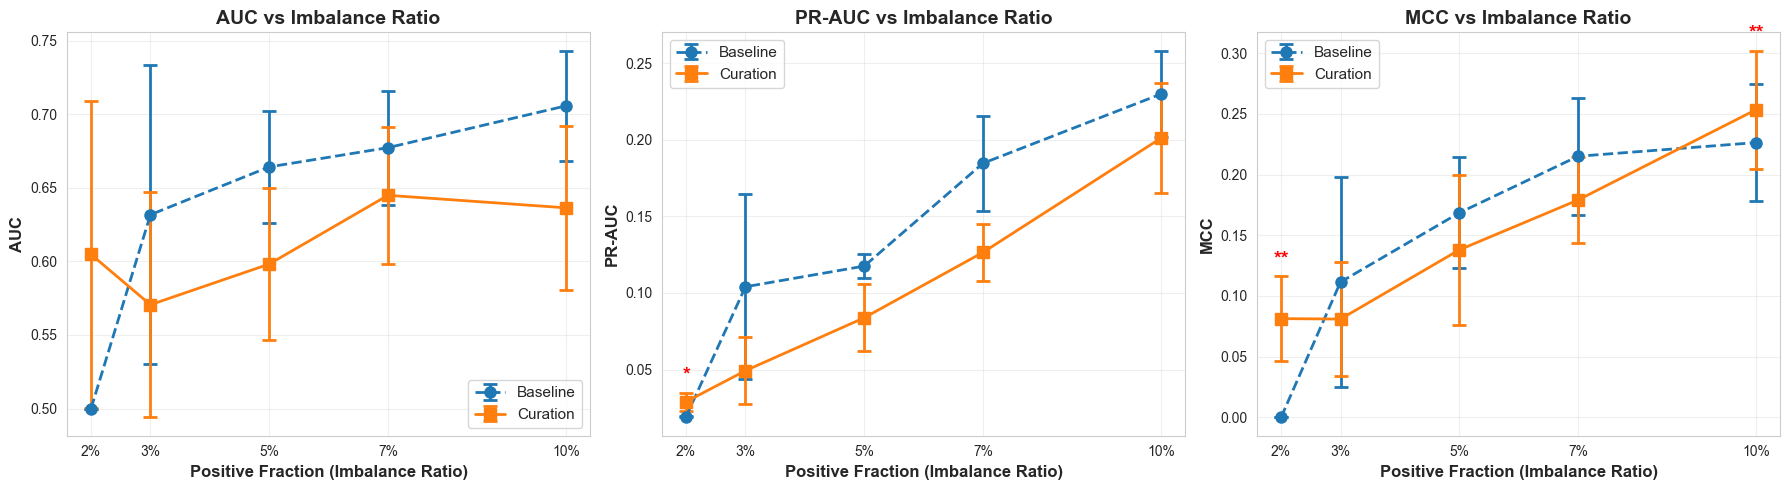


=== SUMMARY TABLE WITH P-VALUES ===


,auc_pvalue,best_mcc_pvalue,pr_auc_pvalue
pos_frac,,,
0.02,0.076264,0.007421,0.025067
0.03,0.783794,0.670521,0.898697
0.05,0.931471,0.764972,0.966349
0.07,0.808271,0.949679,0.978079
0.10,0.996313,0.001118,0.939269


In [20]:
# Create visualizations showing metrics over imbalance ratios
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics_to_plot = ['auc', 'pr_auc', 'best_mcc']
metric_labels = ['AUC', 'PR-AUC', 'MCC']
colors = {'base': '#1f77b4', 'cur': '#ff7f0e'}

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx]
    
    # Aggregate data by pos_frac
    summary_data = []
    for pos_frac in POS_FRACS:
        df_subset = results_df[results_df['pos_frac'] == pos_frac].copy()
        
        base_col = f'base_{metric}'
        cur_col = f'cur_{metric}'
        
        if base_col in df_subset.columns and cur_col in df_subset.columns:
            base_vals = df_subset[base_col].values
            cur_vals = df_subset[cur_col].values
            
            # Calculate mean and std
            summary_data.append({
                'pos_frac': pos_frac,
                'base_mean': base_vals.mean(),
                'base_std': base_vals.std(),
                'cur_mean': cur_vals.mean(),
                'cur_std': cur_vals.std(),
                'base_sem': base_vals.std() / np.sqrt(len(base_vals)),  # Standard error
                'cur_sem': cur_vals.std() / np.sqrt(len(cur_vals))
            })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Plot with error bars (using standard error for confidence intervals)
    # 95% CI ≈ 1.96 * SEM, but we'll show ±1 SEM for cleaner visualization
    # You can change multiplier for different confidence levels
    ci_multiplier = 1.96  # For 95% CI
    
    ax.errorbar(summary_df['pos_frac'], summary_df['base_mean'], 
                yerr=ci_multiplier * summary_df['base_sem'],
                label='Baseline', color=colors['base'], marker='o', 
                linestyle='--', linewidth=2, markersize=8, capsize=5, capthick=2)
    
    ax.errorbar(summary_df['pos_frac'], summary_df['cur_mean'], 
                yerr=ci_multiplier * summary_df['cur_sem'],
                label='Curation', color=colors['cur'], marker='s', 
                linestyle='-', linewidth=2, markersize=8, capsize=5, capthick=2)
    
    # Add significance markers (after plotting to get proper ylim)
    # Store significance info for later
    sig_info = []
    if 'pvalue_df' in locals() or 'pvalue_df' in globals():
        for pos_frac in POS_FRACS:
            pval_row = pvalue_df[(pvalue_df['pos_frac'] == pos_frac) & 
                                 (pvalue_df['metric'] == metric)]
            if not pval_row.empty:
                p_val = pval_row['p_value'].iloc[0]
                if p_val < 0.001:
                    sig_marker = '***'
                elif p_val < 0.01:
                    sig_marker = '**'
                elif p_val < 0.05:
                    sig_marker = '*'
                else:
                    sig_marker = ''
                
                if sig_marker:
                    row = summary_df[summary_df['pos_frac'] == pos_frac].iloc[0]
                    y_max = max(row['base_mean'] + ci_multiplier * row['base_sem'],
                               row['cur_mean'] + ci_multiplier * row['cur_sem'])
                    sig_info.append((pos_frac, y_max, sig_marker))
    
    # Add significance markers after setting ylim
    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
    for pos_frac, y_max, sig_marker in sig_info:
        ax.text(pos_frac, y_max + 0.03 * y_range, sig_marker, 
               ha='center', fontsize=14, fontweight='bold', color='red')
    
    ax.set_xlabel('Positive Fraction (Imbalance Ratio)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{label}', fontsize=12, fontweight='bold')
    ax.set_title(f'{label} vs Imbalance Ratio', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(POS_FRACS)
    ax.set_xticklabels([f'{x:.0%}' for x in POS_FRACS])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, 'heloc_sweep_metrics_comparison.png'), 
            dpi=300, bbox_inches='tight')
print(f"\nSaved visualization to: {os.path.join(RESULTS_ROOT, 'heloc_sweep_metrics_comparison.png')}")
plt.show()

# Create a summary table with p-values
print("\n=== SUMMARY TABLE WITH P-VALUES ===")
summary_table = pvalue_df.pivot(index='pos_frac', columns='metric', values='p_value')
summary_table.columns = [f'{col}_pvalue' for col in summary_table.columns]
display(summary_table)



Saved improvement visualization to: ./heloc_sweep_results/heloc_sweep_improvement.png


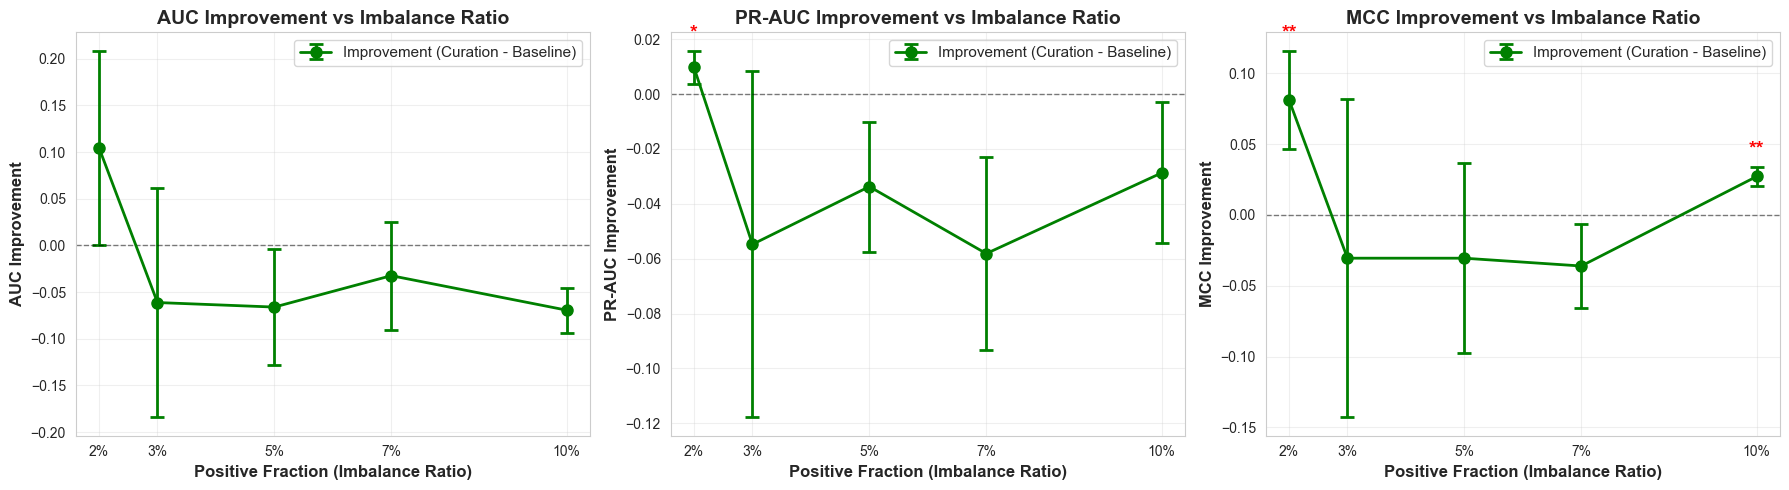

In [21]:
# Additional visualization: Show improvement (difference) over baseline
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (metric, label) in enumerate(zip(metrics_to_plot, metric_labels)):
    ax = axes[idx]
    
    # Calculate differences for each pos_frac
    diff_data = []
    for pos_frac in POS_FRACS:
        df_subset = results_df[results_df['pos_frac'] == pos_frac].copy()
        
        base_col = f'base_{metric}'
        cur_col = f'cur_{metric}'
        
        if base_col in df_subset.columns and cur_col in df_subset.columns:
            base_vals = df_subset[base_col].values
            cur_vals = df_subset[cur_col].values
            differences = cur_vals - base_vals
            
            diff_data.append({
                'pos_frac': pos_frac,
                'mean_diff': differences.mean(),
                'std_diff': differences.std(),
                'sem_diff': differences.std() / np.sqrt(len(differences))
            })
    
    diff_df = pd.DataFrame(diff_data)
    
    # Plot differences with confidence intervals
    ci_multiplier = 1.96  # 95% CI
    ax.errorbar(diff_df['pos_frac'], diff_df['mean_diff'], 
                yerr=ci_multiplier * diff_df['sem_diff'],
                color='green', marker='o', linestyle='-', 
                linewidth=2, markersize=8, capsize=5, capthick=2,
                label='Improvement (Curation - Baseline)')
    
    # Add horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    
    # Add significance markers
    if 'pvalue_df' in locals() or 'pvalue_df' in globals():
        for pos_frac in POS_FRACS:
            pval_row = pvalue_df[(pvalue_df['pos_frac'] == pos_frac) & 
                                 (pvalue_df['metric'] == metric)]
            if not pval_row.empty:
                p_val = pval_row['p_value'].iloc[0]
                if p_val < 0.001:
                    sig_marker = '***'
                elif p_val < 0.01:
                    sig_marker = '**'
                elif p_val < 0.05:
                    sig_marker = '*'
                else:
                    sig_marker = ''
                
                if sig_marker:
                    row = diff_df[diff_df['pos_frac'] == pos_frac].iloc[0]
                    y_max = row['mean_diff'] + ci_multiplier * row['sem_diff']
                    y_range = ax.get_ylim()[1] - ax.get_ylim()[0]
                    ax.text(pos_frac, y_max + 0.03 * y_range, sig_marker, 
                           ha='center', fontsize=14, fontweight='bold', color='red')
    
    ax.set_xlabel('Positive Fraction (Imbalance Ratio)', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{label} Improvement', fontsize=12, fontweight='bold')
    ax.set_title(f'{label} Improvement vs Imbalance Ratio', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(POS_FRACS)
    ax.set_xticklabels([f'{x:.0%}' for x in POS_FRACS])

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_ROOT, 'heloc_sweep_improvement.png'), 
            dpi=300, bbox_inches='tight')
print(f"\nSaved improvement visualization to: {os.path.join(RESULTS_ROOT, 'heloc_sweep_improvement.png')}")
plt.show()
